In [1]:
import sys
sys.path.append('..')

import selex_dca, utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import utils
import selex_dca
import selex_distribution, energy_models, tree, data_loading, training, callback, sampling, diagnostic, tworound_potts

import pickle

import tworound_potts

/home/scrotti/Aptamer2025py/experiments/../selex_dca.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
dtype = torch.float32
device = torch.device('cpu')

In [89]:
experiment_id_idx = 0
experiment_ids = ['Dop8V030', 'Dop8V930', 'Dop8V2430']
experiment_id = experiment_ids[experiment_id_idx]
round_ids = ["ARN", "R01", "R02N"]

In [83]:
with open('./saved/wildtypes_sites.pkl', 'rb') as f:
    wts = pickle.load(f)

wt = wts[experiment_id_idx]
wt_oh = utils.one_hot(wt)
L, q = wt_oh.size()

In [91]:
sequences_all, sequences_unique_all, counts_all, log_multinomial_factors_all = zip(*[utils.sequences_counts_from_file(experiment_id, round_id)
                                                                     for round_id in round_ids])

In [98]:
round_id_idx = 0
sequences_unique = sequences_unique_all[round_id_idx]
counts = counts_all[round_id_idx]

In [99]:
distances = utils.hamming(sequences_unique, wt)

In [100]:
# bins = torch.logspace(0, 4, 30)
# _, bins_counts = torch.histogram(counts.to(dtype), bins=bins)
# buckets_counts = torch.bucketize(counts.to(dtype), bins_counts)
# counts_binned = [counts[buckets_counts==b] for b in range(len(bins_counts))]

In [114]:
bins = torch.arange(L).to(dtype)
_, bins_distances = torch.histogram(distances.to(dtype), bins=bins)
buckets_counts = torch.bucketize(distances.to(dtype), bins_distances)
counts_binned = [counts[buckets_counts==d] for d in range(len(bins))]

In [116]:
bins_avg = torch.tensor([b.to(dtype).mean().item() for b in counts_binned])
bins_var = torch.tensor([b.to(dtype).var().item() for b in counts_binned])

/tmp/ipykernel_1386847/3366349286.py:2: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  bins_var = torch.tensor([b.to(dtype).var().item() for b in counts_binned])


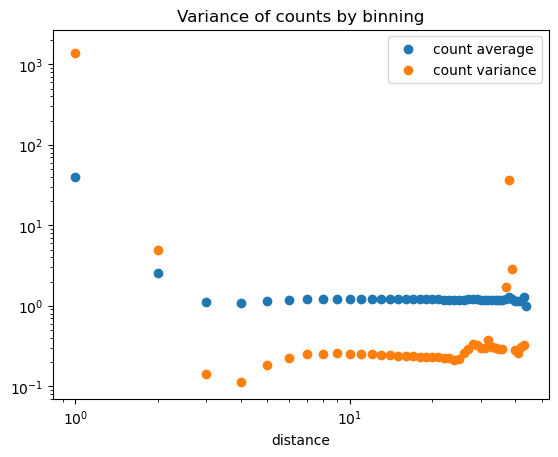

In [117]:
plt.scatter(bins_distances, bins_avg, label='count average')
plt.scatter(bins_distances, bins_var, label='count variance')
plt.yscale('log'); plt.xscale('log')
plt.xlabel('distance')
plt.legend()
plt.title('Variance of counts by binning');

In [66]:
n_samples = 10**5
l = torch.randint(100, (n_samples,)).to(dtype)
counts_gen = torch.poisson(l)

In [73]:
bins = torch.logspace(0, 4, 30)
_, bins_counts = torch.histogram(counts_gen.to(dtype), bins=bins)
buckets_counts = torch.bucketize(counts_gen.to(dtype), bins_counts)
counts_binned = [counts_gen[buckets_counts==b] for b in range(len(bins_counts))]

In [74]:
bins_avg = torch.tensor([b.to(dtype).mean().item() for b in counts_binned])
bins_var = torch.tensor([b.to(dtype).var().item() for b in counts_binned])

/tmp/ipykernel_1386847/3366349286.py:2: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  bins_var = torch.tensor([b.to(dtype).var().item() for b in counts_binned])


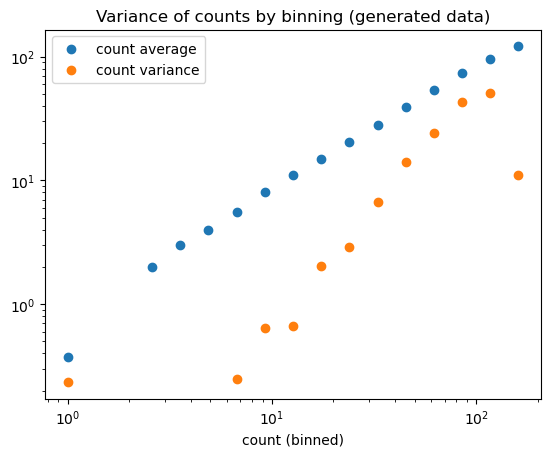

In [76]:
plt.scatter(bins_counts, bins_avg, label='count average')
plt.scatter(bins_counts, bins_var, label='count variance')
plt.yscale('log'); plt.xscale('log')
plt.xlabel('count (binned)')
plt.legend()
plt.title('Variance of counts by binning (generated data)');